In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# 2. Load dataset
data = pd.read_csv("Crop_recommendation.csv")


In [3]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# 3. Preprocessing
print("Dataset Shape:", data.shape)
print("\nNull values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

Dataset Shape: (2200, 8)

Null values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


In [5]:
# Encode labels
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

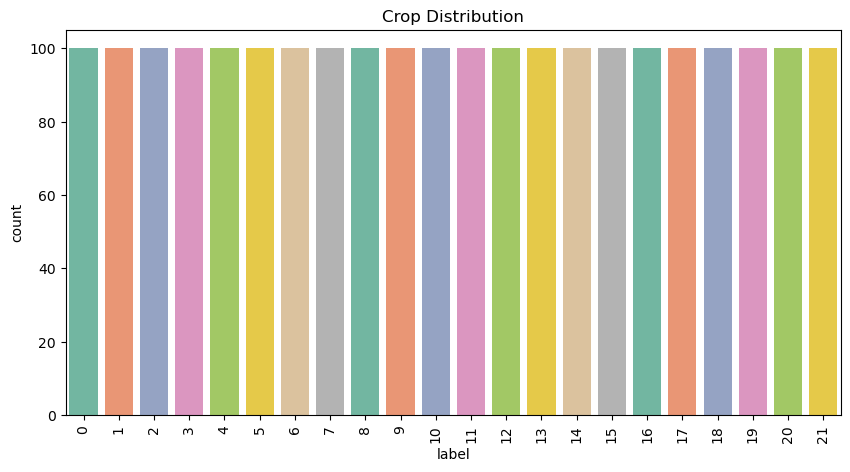

In [6]:
# 4. Visualization
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=data, palette="Set2")
plt.title("Crop Distribution")
plt.xticks(rotation=90)
plt.show()

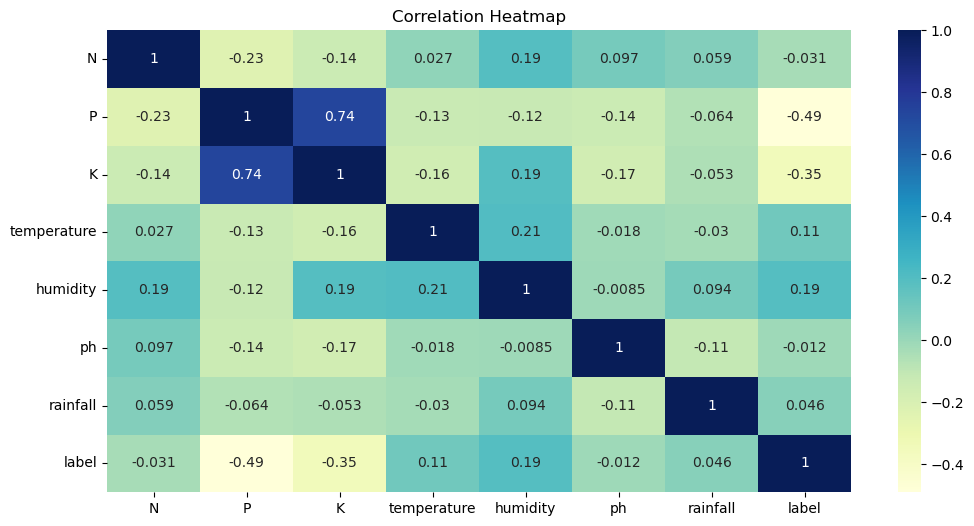

In [7]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()


In [8]:
# 5. Train-Test Split
X = data.drop('label', axis=1)
y = data['label']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# 6. Train Multiple Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

accuracy_scores = {}

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_scores[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9636
Decision Tree Accuracy: 0.9841
Random Forest Accuracy: 0.9932
KNN Accuracy: 0.9568
SVM Accuracy: 0.9682
XGBoost Accuracy: 0.9864


In [13]:
# 7. Select Best Model
best_model_name = max(accuracy_scores, key=accuracy_scores.get)
best_model = models[best_model_name]
print("\nBest Model:", best_model_name)


Best Model: Random Forest


In [14]:
# 8. Confusion Matrix & Classification Report
y_pred = best_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
  

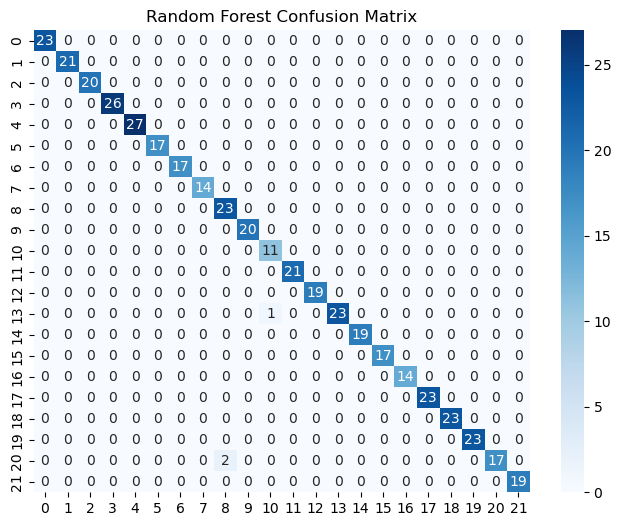

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_model_name} Confusion Matrix")
plt.show()


In [18]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    # Create dataframe with correct feature names
    features = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                            columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])
    # Scale
    scaled = scaler.transform(features)
    # Predict
    prediction = best_model.predict(scaled)
    crop = le.inverse_transform(prediction)[0]
    return crop


In [19]:
# Example Prediction
print("\nRecommended Crop:", recommend_crop(90, 42, 43, 20, 80, 6.5, 200))


Recommended Crop: rice


In [20]:
import pickle

# Save best model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Model, Scaler, and LabelEncoder saved successfully!")


✅ Model, Scaler, and LabelEncoder saved successfully!
